# **Importing and Exploring the Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("orders_raw.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'orders_raw.csv'

In [17]:
df = pd.read_csv("orders_raw.csv")
df.info()
df.describe()
df['status'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


,count
status,
Delivered,439
Cancelled,43
Pending,26


1. There are more than 500 entries i.e. 508, implying existance of duplicates.
2. There are missing values in amount_inr column
3. There are suspiciously large amount_inr values that may be outliers.
4. Mixed casing in city and category with leading and trailing spaces

## **Removing Duplicates**

In [18]:
print("No. of duplicated rows:",df.duplicated(subset='order_id').sum())
df = df.drop_duplicates(subset='order_id', keep= 'first')
print("Shape after deletion of duplicates")
df.shape

No. of duplicated rows: 8
Shape after deletion of duplicates


(500, 11)

# **Fixing Casing**

In [19]:
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()
df["city"].unique().tolist()


['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai']

In [20]:
df["category"].unique().tolist()

['Snacks & Beverages',
 'Household Essentials',
 'Bakery',
 'Personal Care',
 'Fruits & Vegetables',
 'Dairy & Eggs']

# **Handling Missing Values**

In [21]:
print("No. of missing values in amount_inr: ", df["amount_inr"].isnull().sum())
rev = df.dropna(subset=["amount_inr"])

No. of missing values in amount_inr:  10


# **Outliers**

In [22]:
import warnings
warnings.filterwarnings('ignore')
Q1 = rev[rev["status"]=="Delivered"]["amount_inr"].quantile(0.25)
Q3 = rev[rev["status"]=="Delivered"]["amount_inr"].quantile(0.75)
IQR = Q3-Q1
upper_fence = Q3 + 1.5*IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("upper_fence :", upper_fence)
rows_capped = (rev[(rev["status"]=='Delivered') & (rev["amount_inr"]> upper_fence)]["order_id"]).count()
print("rows_capped :" ,rows_capped)
rev["amount_inr"] = rev["amount_inr"].clip(upper=upper_fence)





Q1: 90.0
Q3: 275.0
upper_fence : 552.5
rows_capped : 16


# **Parsing Date and creating Derived columns**

In [33]:
df["order_date"] = pd.to_datetime(df["order_date"])
rev["month"] = df["order_date"].dt.month
rev["month_name"] =  df["order_date"].dt.month_name()
rev["revenue_per_unit"] = rev[rev["status"]=='Delivered']["amount_inr"]/rev["quantity"]
df

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2026-01-15,Siya,Bengaluru,Personal Care,18,2,80.0,Credit Card,Delivered,4.0,1,January,40.0
496,497,2026-06-05,Ayaan,Bengaluru,Personal Care,18,5,200.0,UPI,Delivered,2.0,6,June,40.0
497,498,2026-06-29,Ayaan,Bengaluru,Fruits & Vegetables,1,2,100.0,UPI,Delivered,3.0,6,June,50.0
498,499,2026-02-12,Varun,Hyderabad,Household Essentials,22,3,390.0,Debit Card,Delivered,3.0,2,February,130.0


# **Group By**

In [34]:
rev[rev["status"]=='Delivered'].groupby("category").agg(total_revenue=("amount_inr",sum)).sort_values("total_revenue", ascending = False).head(1)

,total_revenue
category,
Household Essentials,20910.0


In [35]:
products = pd.read_csv("products.csv")
merge_df = pd.merge(rev, products, on = "product_id", how="left")
merge_df[merge_df["status"]=='Delivered'].groupby("supplier").agg(total_revenue_per_supplier=("amount_inr",sum)).sort_values("total_revenue_per_supplier", ascending = False).head(1)


,total_revenue_per_supplier
supplier,
HomeEssentials Traders,20910.0


# **Visualize**

**1. Bar chart of category v/s revenue**

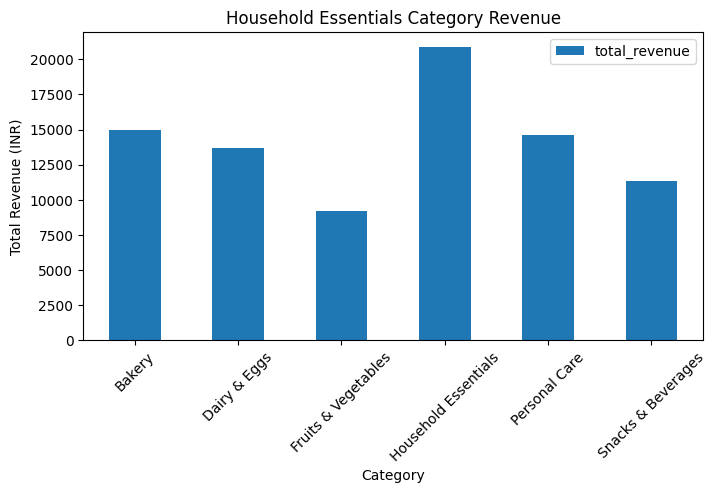

In [36]:
cat_vs_rev = rev[rev["status"]== "Delivered"].groupby("category").agg(total_revenue=("amount_inr",sum))
cat_vs_rev.plot(kind = "bar",figsize=(8,4))

plt.title("Household Essentials Category Revenue")
plt.xlabel("Category")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)

plt.show()


 **2. Line chart on monthly revenue trend**

In [37]:
print(rev.columns)

Index(['order_id', 'order_date', 'customer_name', 'city', 'category',
       'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status',
       'rating', 'month', 'month_name', 'revenue_per_unit'],
      dtype='object')


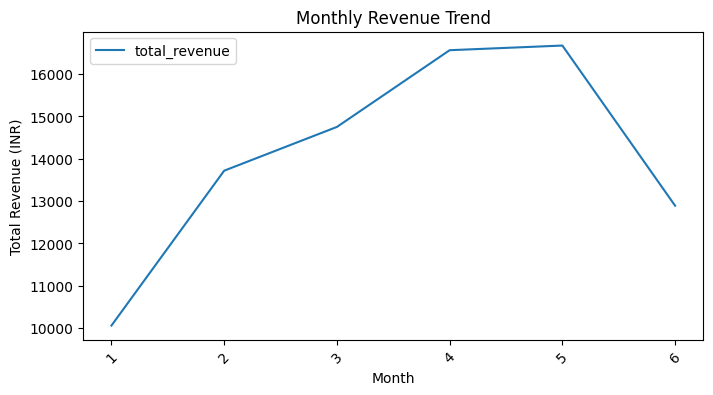

In [38]:
monthly_revenue_trend = rev[rev["status"]== "Delivered"].groupby("month").agg(total_revenue=("amount_inr",'sum'))
monthly_revenue_trend.plot(kind = "line",figsize=(8,4))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")
plt.xticks(rotation=45)

plt.show()

 **3. Category wise total order count on monthly basis**

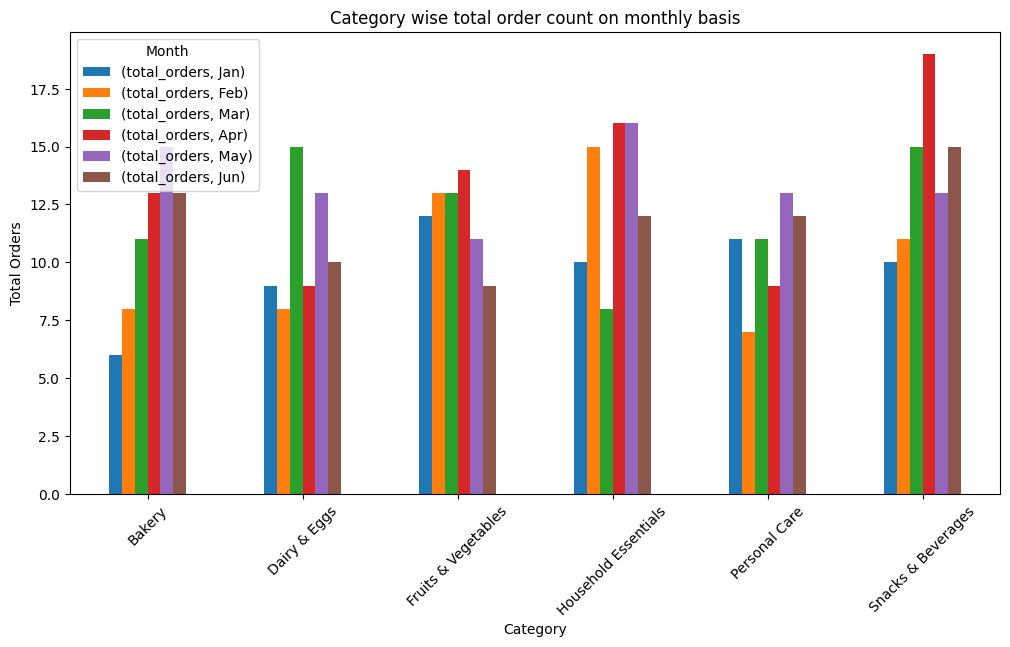

In [39]:
chart3 = rev[rev["status"]== "Delivered"].groupby(["category","month"]).agg(total_orders=("order_id",'count'))
chart3_grouped = chart3.unstack("month")

month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
chart3_grouped = chart3_grouped.rename(columns= month_map)
chart3_grouped.plot(kind = "bar",figsize=(12,6))

plt.title("Category wise total order count on monthly basis")
plt.xlabel("Category")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.legend(title = "Month")
plt.show()

# **Insights**

### Observation 1

**What:** Household Essentials generated the highest Delivered revenue of **₹20,910**, while Fruits & Vegetables generated the lowest at **₹9,170**.

**Why it matters:** Revenue performance differs significantly across categories. Household Essentials is the strongest revenue contributor, whereas Fruits & Vegetables may need further investigation.

**Next step:** Analyse product-level sales, availability, pricing, and supplier performance in Fruits & Vegetables to identify the reasons for its lower revenue.

### Observation 2

**What:** Monthly Delivered revenue increased from **₹10,059.50 in January** to a peak of **₹16,668.50 in May**, before falling to **₹12,888 in June**.

**Why it matters:** Revenue was not consistent throughout the six-month period. The decline after May may indicate changes in customer demand, promotions, or product availability.

**Next step:** Compare order volume, product availability, and promotional activity between May and June to understand the decline.

### Observation 3

**What:** Snacks & Beverages recorded the highest monthly Delivered order count in the dataset, reaching **19 orders in April**. Household Essentials recorded **16 orders in April and May**, while Bakery reached its highest count of **15 orders in May**.

**Why it matters:** High order volume does not necessarily mean the highest revenue. Order count and revenue should be analysed together to understand differences in average order value.

**Next step:** Compare category-wise revenue per order, especially for Snacks & Beverages and Household Essentials, to determine whether high order volume is translating into strong revenue.